In [11]:
import numpy as np

def parse_raw_binary(raw_path):
    with open(raw_path, 'rb') as f:
        raw = f.read()

    split = raw.split(b'Binary:\n')
    header_text = split[0].decode('latin-1')
    binary_data = split[1]

    variables = []
    num_vars = 0
    num_points = 0
    in_vars = False


    for line in header_text.splitlines():
        line = line.strip()
        if line.startswith('No. Variables:'):
            num_vars = int(line.split(':')[1].strip())
        elif line.startswith('No. Points:'):
            num_points = int(line.split(':')[1].strip())
        elif line.startswith('Variables:'):
            in_vars = True
            continue
        elif in_vars and line:
            parts = line.split()
            if parts and parts[0].isdigit():
                variables.append(parts[1].lower())

    floats = np.frombuffer(binary_data, dtype=np.float64)
    matrix = floats[:num_vars * num_points].reshape((num_points, num_vars))

    data = {}
    for i, var in enumerate(variables):
        data[var] = matrix[:, i]

    return data

In [12]:
data = parse_raw_binary('test_tran.raw')

print("Variables: ", list(data.keys()))
print("Num points: ", len(data['time']))
print()

for i in range(5):
    print(f"t={data['time'][i]*1e6:.4f} µs   "
          f"v(in)={data['v(in)'][i]:.4f} V   "
          f"v(vb)={data['v(vb)'][i]:.4f} V   "
          f"i(vs)={data['i(vs)'][i]*1e3:.4f} mA   "
         )

Variables:  ['time', 'v(in)', 'v(vb)', 'i(vs)']
Num points:  5011

t=0.0050 µs   v(in)=5.0000 V   v(vb)=0.0000 V   i(vs)=-1.0000 mA   
t=0.0100 µs   v(in)=5.0000 V   v(vb)=0.0001 V   i(vs)=-1.0000 mA   
t=0.0200 µs   v(in)=5.0000 V   v(vb)=0.0002 V   i(vs)=-1.0000 mA   
t=0.0400 µs   v(in)=5.0000 V   v(vb)=0.0004 V   i(vs)=-0.9999 mA   
t=0.0800 µs   v(in)=5.0000 V   v(vb)=0.0008 V   i(vs)=-0.9998 mA   


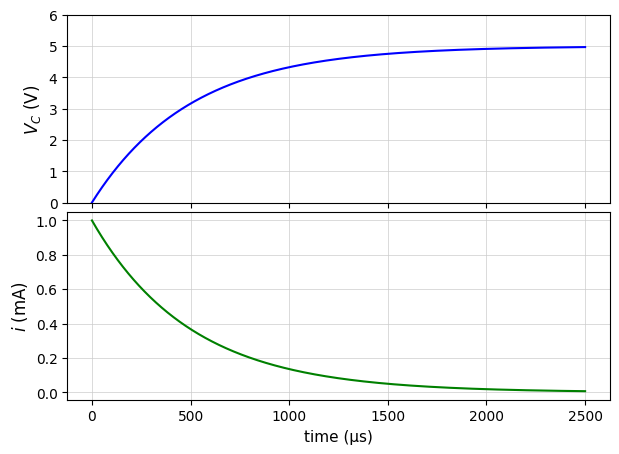

In [13]:
import matplotlib.pyplot as plt

time = data['time']
vb = data['v(vb)']
i_vs = data['i(vs)']

fig, axes = plt.subplots(2, 1, figsize=(7,5), sharex=True)
fig.subplots_adjust(hspace=0.05)

axes[0].plot(time*1e6, vb, color='blue', linewidth=1.5, label=r'$V_C$')
axes[0].set_ylabel('$V_C$ (V)', fontsize=12)
axes[0].set_ylim(0,6)
axes[0].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)
axes[0].tick_params(labelbottom=False)

axes[1].plot(time * 1e6, -i_vs * 1e3, color='green', linewidth=1.5, label=r'$i$')
axes[1].set_ylabel('$i$ (mA)', fontsize=12)
axes[1].set_xlabel('time (µs)', fontsize=11)
axes[1].grid(color='#CCCCCC', linestyle='solid', linewidth=0.5)

plt.show()